共获取 26 条图片数据


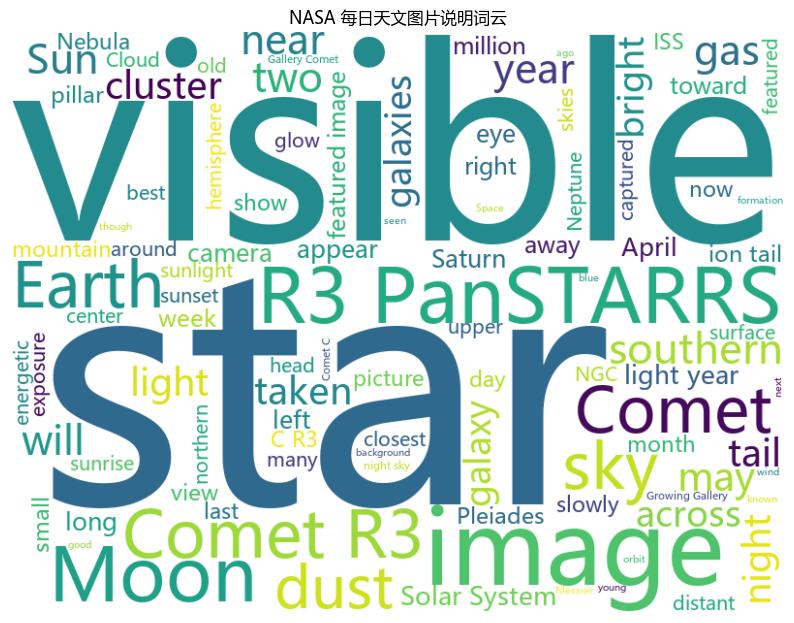

media_type
image    26
video     5
Name: count, dtype: int64
1: https://apod.nasa.gov/apod/image/2604/R3Panstarrs_Rodrigues_960.jpg
2: https://apod.nasa.gov/apod/image/2604/Ngc602_Hubble_960.jpg
3: https://apod.nasa.gov/apod/image/2604/CometR3_Hamdi_960.jpg
4: https://apod.nasa.gov/apod/image/2604/iss_moon_transit_zoom.jpeg
5: https://apod.nasa.gov/apod/image/2604/Southern_Celestial_Pole_800.jpg
6: https://apod.nasa.gov/apod/image/2604/M82_V3_1024.jpg
7: https://apod.nasa.gov/apod/image/2604/PanstarrsPlanetsPerrotLab1024.jpg
8: https://apod.nasa.gov/apod/image/2604/EyeOnMW_Claro_960.jpg
9: https://apod.nasa.gov/apod/image/2604/ValleyComet_Chakrabarti_960.jpg
10: https://apod.nasa.gov/apod/image/2604/TripleArchAlps_Fux_1080.jpg
11: https://apod.nasa.gov/apod/image/2604/noirlab2610c_1024.jpg
12: https://apod.nasa.gov/apod/image/2604/GHR3777LunaPleiadi_101400_1024.jpg
13: https://apod.nasa.gov/apod/image/2604/sequenzasunsetnebida1024.jpg
14: https://apod.nasa.gov/apod/image/2604/MysticPil

In [6]:
# ======================================
# 项目名称：NASA APOD 天文图文爬虫与词云可视化
# 项目简介：
#   调用 NASA 官方开放 APOD 接口，自动爬取近30天每日天文图文数据
#   流程包含：接口请求 → 循环日期爬取 → 结构化数据整理 → 筛选天文图片 → 
#            文案文本合并生成词云 → 媒体类型统计与单日详情查询
# 安全规范：API密钥使用占位符，避免敏感信息泄露
# 技术栈：
#   Requests网络请求、Pandas数据整理、WordCloud词云生成、
#   Matplotlib绘图、datetime日期处理、Jupyter交互式展示
# ======================================
import requests
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
import datetime
import matplotlib.font_manager as fm

# 设置字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# ======================================
# 密匙与时间范围配置
# 参数说明：
#   datetime.date.today：获取当前日期
#   datetime.timedelta：时间差计算
# ======================================
# API 密匙配置（需自行申请替换）
API_KEY = "YOUR_API_KEY"
# 设置要获取的日期范围（30天）
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=30)
# 自定义列表用于存储每一天的数据
records = []


# ======================================
# 循环遍历日期，逐天请求 NASA APOD 接口
# ======================================
# 循环从 start_date 到 end_date 的每一天
current_date = start_date
while current_date <= end_date:
    # 创建 API 请求 URL
    url = f"https://api.nasa.gov/planetary/apod?api_key={API_KEY}&date={current_date}"
    
    # 发送 GET 请求
    response = requests.get(url)
    
    # 检查是否成功（状态码 200）
    if response.status_code == 200:
        data = response.json()   # 将返回的 JSON 数据解析为 Python 字典
        # 存入日期、标题、文案、链接、媒体类型
        records.append({'date': current_date, 
                        'title': data.get('title', ''), 
                        'explanation': data.get('explanation', ''), 
                        'url': data.get('url', ''), 
                        'media_type': data.get('media_type', '')  # 可能是 'image' 或 'video'
                       })
    else:
        print(f"请求失败：{current_date}，状态码：{response.status_code}")
    
    # 移动到下一天
    current_date += datetime.timedelta(days=1)


# ======================================
# 转换为 DataFrame
# ======================================
df_apod = pd.DataFrame(records)


# ======================================
# 词云可视化：筛选图片数据 ＋ 合并说明文本
# 参数说明：
#   .tolist：将 Series 转换为 Python 列表
#   colormap：配色
#   .generate：将传入的文本字符串转换为词云图像
#   interpolation：填充方式
# ======================================
# 只保留 media_type 为 'image' 的行
df_images = df_apod[df_apod['media_type'] == 'image'].copy()
print(f"共获取 {len(df_images)} 条图片数据")

# 将所有图片的 explanation 文本合并成一个字符串（用空格做分隔符）
all_text = " ".join(df_images['explanation'].dropna().tolist())

# 生成词云对象
wordcloud = WordCloud(width=800,
                      height=600,
                      background_color='white',
                      max_words=100,
                      colormap='viridis'
                     ).generate(all_text)
# 绘制词云
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('NASA 每日天文图片说明词云')
plt.show()


# ======================================
# 类型统计 ＋ 日期查看 ＋ 展示图片 ＋ 单日查询
# 参数说明：
#   .value_counts()：统计 media_type 列中每个值的出现次数
#   .reset_index(drop=True)：重置 DataFrame 的行索引，从0开始
#   .iloc[i]：取第 i 行
# ======================================
# 查看共找到多少视频文件，多少图片文件
print(df_apod['media_type'].value_counts())
# 打印所有日期
# print(df_apod['date'].tolist())

# 导入 IPython 内置的显示工具，可以在 notebook 中直接渲染图片
from IPython.display import Image, display

# 只选取 media_type 为 'image' 的行
df_images = df_apod[df_apod['media_type'] == 'image'].reset_index(drop=True)

# 循环最多26次，这里 min(26, len(df_images)) 确保不超过实际图片数
#for i in range(min(26, len(df_images))):
#    row = df_images.iloc[i]
#    print(f"日期: {row['date']}, 标题: {row['title']}")
#    display(Image(url=row['url'], width=400))

# 查看所有图片的 URL
for i, url in enumerate(df_images['url']):
    print(f"{i+1}: {url}")

# 查看某一天的数据详情（视频or图片）以 4 月 9 日为例
april_9 = df_apod[df_apod['date'] == datetime.date(2026, 4, 9)]
print(april_9[['date', 'title', 'media_type', 'url']])